In [1]:
import os
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern, hog
from skimage.transform import resize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, balanced_accuracy_score,
    confusion_matrix, roc_curve
)
import warnings
warnings.filterwarnings("ignore")

SEED = 42
N_PACIENTES = 150
N_SLICES_POR_PACIENTE = 15
TAMANHO_IMAGEM = 128
WINDOW_CENTER = 400
WINDOW_WIDTH = 1800

base_competicao = "/kaggle/input/competitions/rsna-2022-cervical-spine-fracture-detection"
base_imagens = os.path.join(base_competicao, "train_images")
print("Configuração carregada.")

Configuração carregada.


In [2]:
train = pd.read_csv(os.path.join(base_competicao, "train.csv"))
print(f"Total de pacientes: {len(train)}")
print(train["patient_overall"].value_counts())
print(train["patient_overall"].value_counts(normalize=True))

Total de pacientes: 2019
patient_overall
0    1058
1     961
Name: count, dtype: int64
patient_overall
0    0.524022
1    0.475978
Name: proportion, dtype: float64


In [3]:
amostra, _ = train_test_split(
    train, train_size=N_PACIENTES, stratify=train["patient_overall"], random_state=SEED
)
treino_ids, val_ids = train_test_split(
    amostra, test_size=0.2, stratify=amostra["patient_overall"], random_state=SEED
)
treino_ids = treino_ids.copy()
val_ids = val_ids.copy()
treino_ids["split"] = "train"
val_ids["split"] = "val"
particao = pd.concat([treino_ids, val_ids]).reset_index(drop=True)
particao.to_csv("/kaggle/working/particao_congelada.csv", index=False)
print(f"Amostra: {len(amostra)} | Treino: {len(treino_ids)} | Validação: {len(val_ids)}")

Amostra: 150 | Treino: 120 | Validação: 30


In [4]:
def aplicar_janela(img_hu, center, width):
    minimo = center - width / 2
    maximo = center + width / 2
    img = np.clip(img_hu, minimo, maximo)
    return (img - minimo) / (maximo - minimo)

def extrair_histograma_slice(img):
    feats = {}
    hist, _ = np.histogram(img, bins=10, range=(0, 1))
    hist = hist / (hist.sum() + 1e-8)
    for i, v in enumerate(hist):
        feats[f"hist_{i}"] = v
    return feats

def processar_paciente_hist(study_uid):
    pasta = os.path.join(base_imagens, study_uid)
    if not os.path.exists(pasta):
        return None
    arquivos = sorted(os.listdir(pasta))
    if len(arquivos) <= N_SLICES_POR_PACIENTE:
        selecionados = arquivos
    else:
        indices = np.linspace(0, len(arquivos) - 1, N_SLICES_POR_PACIENTE).astype(int)
        selecionados = [arquivos[i] for i in indices]

    features_slices = []
    for arq in selecionados:
        try:
            ds = pydicom.dcmread(os.path.join(pasta, arq))
            slope = float(getattr(ds, "RescaleSlope", 1))
            intercept = float(getattr(ds, "RescaleIntercept", 0))
            img_hu = ds.pixel_array.astype(float) * slope + intercept
            img_janela = aplicar_janela(img_hu, WINDOW_CENTER, WINDOW_WIDTH)
            img_resized = resize(img_janela, (TAMANHO_IMAGEM, TAMANHO_IMAGEM), anti_aliasing=True)
            features_slices.append(extrair_histograma_slice(img_resized))
        except Exception:
            continue

    if not features_slices:
        return None
    df_slices = pd.DataFrame(features_slices)
    agregado = {}
    for col in df_slices.columns:
        agregado[f"{col}_mean"] = df_slices[col].mean()
        agregado[f"{col}_std"] = df_slices[col].std()
    return agregado

print("Funções de pré-processamento (Semana 2: apenas histograma) definidas.")

Funções de pré-processamento (Semana 2: apenas histograma) definidas.


In [5]:
linhas = []
for idx, row in particao.iterrows():
    feats = processar_paciente_hist(row["StudyInstanceUID"])
    if feats is not None:
        feats["StudyInstanceUID"] = row["StudyInstanceUID"]
        feats["patient_overall"] = row["patient_overall"]
        feats["split"] = row["split"]
        linhas.append(feats)
    if (idx + 1) % 20 == 0:
        print(f"{idx + 1}/{len(particao)} pacientes processados")

df_features_semana2 = pd.DataFrame(linhas)
df_features_semana2.to_csv("/kaggle/working/features_semana2_histograma.csv", index=False)
print(f"Concluído! Shape: {df_features_semana2.shape}")

20/150 pacientes processados
40/150 pacientes processados
60/150 pacientes processados
80/150 pacientes processados
100/150 pacientes processados
120/150 pacientes processados
140/150 pacientes processados
Concluído! Shape: (113, 23)


In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score

colunas_meta = ["StudyInstanceUID", "patient_overall", "split"]
colunas_features = [c for c in df_features_semana2.columns if c not in colunas_meta]

treino = df_features_semana2[df_features_semana2["split"] == "train"]
val = df_features_semana2[df_features_semana2["split"] == "val"]
X_treino = treino[colunas_features].fillna(0)
y_treino = treino["patient_overall"]
X_val = val[colunas_features].fillna(0)
y_val = val["patient_overall"]

print("=== BASELINE TRIVIAL ===")
baseline = DummyClassifier(strategy="most_frequent", random_state=SEED)
baseline.fit(X_treino, y_treino)
pred_baseline = baseline.predict(X_val)
print("Acurácia balanceada:", balanced_accuracy_score(y_val, pred_baseline))
print("F1:", f1_score(y_val, pred_baseline, zero_division=0))

print("\n=== PRIMEIRO CLASSIFICADOR (Regressão Logística, apenas histograma) ===")
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced"))
])
modelo.fit(X_treino, y_treino)
proba = modelo.predict_proba(X_val)[:, 1]
pred = modelo.predict(X_val)
print("AUC-ROC:", roc_auc_score(y_val, proba))
print("F1:", f1_score(y_val, pred, zero_division=0))
print("Acurácia balanceada:", balanced_accuracy_score(y_val, pred))

=== BASELINE TRIVIAL ===
Acurácia balanceada: 0.5
F1: 0.6470588235294118

=== PRIMEIRO CLASSIFICADOR (Regressão Logística, apenas histograma) ===
AUC-ROC: 0.5
F1: 0.4444444444444444
Acurácia balanceada: 0.5568181818181819


In [7]:
def extrair_features_completas_slice(img):
    feats = {}

    # Histograma (já tínhamos)
    hist, _ = np.histogram(img, bins=10, range=(0, 1))
    hist = hist / (hist.sum() + 1e-8)
    for i, v in enumerate(hist):
        feats[f"hist_{i}"] = v

    # LBP (textura) — nova
    img_uint8 = (img * 255).astype(np.uint8)
    lbp = local_binary_pattern(img_uint8, P=8, R=1, method="uniform")
    lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10))
    lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-8)
    for i, v in enumerate(lbp_hist):
        feats[f"lbp_{i}"] = v

    # HOG (forma/gradiente) — nova
    hog_feats = hog(img, pixels_per_cell=(32, 32), cells_per_block=(2, 2), feature_vector=True)
    for i, v in enumerate(hog_feats):
        feats[f"hog_{i}"] = v

    return feats

def processar_paciente_completo(study_uid):
    pasta = os.path.join(base_imagens, study_uid)
    if not os.path.exists(pasta):
        return None
    arquivos = sorted(os.listdir(pasta))
    if len(arquivos) <= N_SLICES_POR_PACIENTE:
        selecionados = arquivos
    else:
        indices = np.linspace(0, len(arquivos) - 1, N_SLICES_POR_PACIENTE).astype(int)
        selecionados = [arquivos[i] for i in indices]

    features_slices = []
    for arq in selecionados:
        try:
            ds = pydicom.dcmread(os.path.join(pasta, arq))
            slope = float(getattr(ds, "RescaleSlope", 1))
            intercept = float(getattr(ds, "RescaleIntercept", 0))
            img_hu = ds.pixel_array.astype(float) * slope + intercept
            img_janela = aplicar_janela(img_hu, WINDOW_CENTER, WINDOW_WIDTH)
            img_resized = resize(img_janela, (TAMANHO_IMAGEM, TAMANHO_IMAGEM), anti_aliasing=True)
            features_slices.append(extrair_features_completas_slice(img_resized))
        except Exception:
            continue

    if not features_slices:
        return None
    df_slices = pd.DataFrame(features_slices)
    agregado = {}
    for col in df_slices.columns:
        agregado[f"{col}_mean"] = df_slices[col].mean()
        agregado[f"{col}_std"] = df_slices[col].std()
    return agregado

print("Funções completas (histograma + LBP + HOG) definidas.")

Funções completas (histograma + LBP + HOG) definidas.


In [8]:
linhas = []
for idx, row in particao.iterrows():
    feats = processar_paciente_completo(row["StudyInstanceUID"])
    if feats is not None:
        feats["StudyInstanceUID"] = row["StudyInstanceUID"]
        feats["patient_overall"] = row["patient_overall"]
        feats["split"] = row["split"]
        linhas.append(feats)
    if (idx + 1) % 20 == 0:
        print(f"{idx + 1}/{len(particao)} pacientes processados")

df_features = pd.DataFrame(linhas)
df_features.to_csv("/kaggle/working/features_baseline.csv", index=False)
print(f"Concluído! Shape: {df_features.shape}")

20/150 pacientes processados
40/150 pacientes processados
60/150 pacientes processados
80/150 pacientes processados
100/150 pacientes processados
120/150 pacientes processados
140/150 pacientes processados
Concluído! Shape: (113, 691)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix

colunas_meta = ["StudyInstanceUID", "patient_overall", "split"]
colunas_features = [c for c in df_features.columns if c not in colunas_meta]

treino = df_features[df_features["split"] == "train"]
val = df_features[df_features["split"] == "val"]
X_treino = treino[colunas_features].fillna(0)
y_treino = treino["patient_overall"]
X_val = val[colunas_features].fillna(0)
y_val = val["patient_overall"]

modelos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced"))
    ]),
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight="balanced"))
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=SEED, class_weight="balanced"))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados = []

print("=== VALIDAÇÃO CRUZADA (5 dobras no treino) ===")
for nome, pipe in modelos.items():
    scores_auc = cross_val_score(pipe, X_treino, y_treino, cv=cv, scoring="roc_auc")
    print(f"{nome}: AUC-ROC = {scores_auc.mean():.3f} +/- {scores_auc.std():.3f}")
    resultados.append({"modelo": nome, "auc_cv_mean": scores_auc.mean(), "auc_cv_std": scores_auc.std()})

print("\n=== AVALIAÇÃO FINAL NA VALIDAÇÃO ===")
for nome, pipe in modelos.items():
    pipe.fit(X_treino, y_treino)
    pred = pipe.predict(X_val)
    proba = pipe.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, proba)
    f1 = f1_score(y_val, pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_val, pred)
    print(f"\n--- {nome} ---")
    print(f"AUC-ROC: {auc:.3f} | F1: {f1:.3f} | Acurácia balanceada: {bal_acc:.3f}")
    print("Matriz de confusão:")
    print(confusion_matrix(y_val, pred))
    for r in resultados:
        if r["modelo"] == nome:
            r["auc_val"] = auc
            r["f1_val"] = f1
            r["balanced_acc_val"] = bal_acc

tabela_final = pd.DataFrame(resultados)
tabela_final.to_csv("/kaggle/working/tabela_resultados.csv", index=False)
print("\n=== TABELA FINAL ===")
print(tabela_final)

=== VALIDAÇÃO CRUZADA (5 dobras no treino) ===
Regressão Logística: AUC-ROC = 0.624 +/- 0.096
Random Forest: AUC-ROC = 0.639 +/- 0.106
SVM (RBF): AUC-ROC = 0.611 +/- 0.092

=== AVALIAÇÃO FINAL NA VALIDAÇÃO ===

--- Regressão Logística ---
AUC-ROC: 0.705 | F1: 0.696 | Acurácia balanceada: 0.697
Matriz de confusão:
[[8 4]
 [3 8]]

--- Random Forest ---
AUC-ROC: 0.799 | F1: 0.727 | Acurácia balanceada: 0.739
Matriz de confusão:
[[9 3]
 [3 8]]

--- SVM (RBF) ---
AUC-ROC: 0.780 | F1: 0.583 | Acurácia balanceada: 0.568
Matriz de confusão:
[[6 6]
 [4 7]]

=== TABELA FINAL ===
                modelo  auc_cv_mean  auc_cv_std   auc_val    f1_val  \
0  Regressão Logística     0.623858    0.096106  0.704545  0.695652   
1        Random Forest     0.638549    0.106247  0.799242  0.727273   
2            SVM (RBF)     0.611327    0.091501  0.780303  0.583333   

   balanced_acc_val  
0          0.696970  
1          0.738636  
2          0.568182  


In [10]:
grupos = {
    "Apenas Histograma": [c for c in df_features.columns if c.startswith("hist_")],
    "Apenas LBP": [c for c in df_features.columns if c.startswith("lbp_")],
    "Apenas HOG": [c for c in df_features.columns if c.startswith("hog_")],
    "Todos combinados": [c for c in df_features.columns if c not in colunas_meta],
}

print("=== ABLAÇÃO: contribuição de cada família de descritores (Random Forest, CV no treino) ===")
resultados_ablacao = []
for nome_grupo, colunas in grupos.items():
    X = treino[colunas].fillna(0)
    modelo_ablacao = RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight="balanced")
    scores = cross_val_score(modelo_ablacao, X, y_treino, cv=cv, scoring="roc_auc")
    print(f"{nome_grupo}: AUC-ROC = {scores.mean():.3f} +/- {scores.std():.3f}  ({len(colunas)} features)")
    resultados_ablacao.append({"grupo": nome_grupo, "auc_mean": scores.mean(), "auc_std": scores.std(), "n_features": len(colunas)})

pd.DataFrame(resultados_ablacao).to_csv("/kaggle/working/ablacao.csv", index=False)

=== ABLAÇÃO: contribuição de cada família de descritores (Random Forest, CV no treino) ===
Apenas Histograma: AUC-ROC = 0.511 +/- 0.151  (20 features)
Apenas LBP: AUC-ROC = 0.552 +/- 0.117  (20 features)
Apenas HOG: AUC-ROC = 0.630 +/- 0.068  (648 features)
Todos combinados: AUC-ROC = 0.639 +/- 0.106  (688 features)


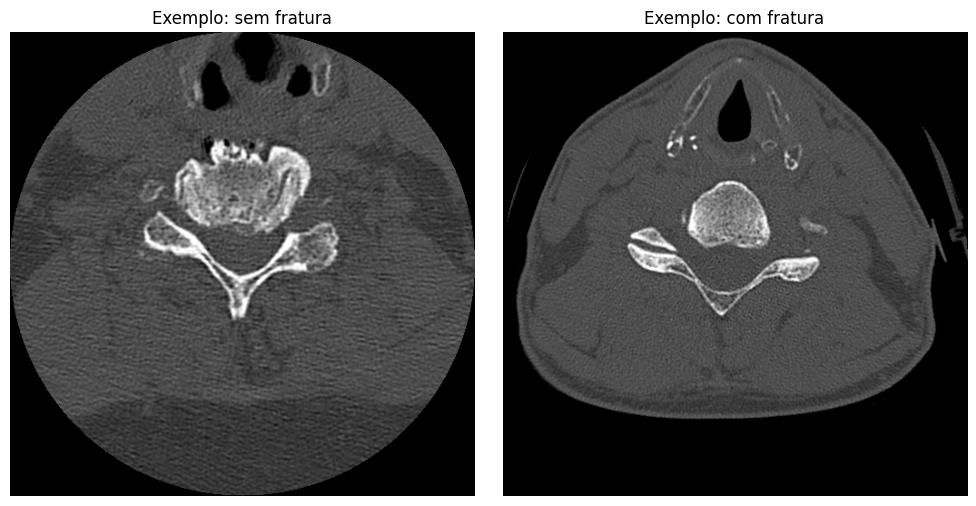

In [11]:
paciente_sem_fratura = particao[particao["patient_overall"] == 0]["StudyInstanceUID"].iloc[0]
paciente_com_fratura = particao[particao["patient_overall"] == 1]["StudyInstanceUID"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, study_uid, titulo in zip(
    axes,
    [paciente_sem_fratura, paciente_com_fratura],
    ["Exemplo: sem fratura", "Exemplo: com fratura"]
):
    pasta = os.path.join(base_imagens, study_uid)
    arquivos = sorted(os.listdir(pasta))
    ds = pydicom.dcmread(os.path.join(pasta, arquivos[len(arquivos) // 2]))
    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    img_hu = ds.pixel_array.astype(float) * slope + intercept
    img_janela = np.clip(img_hu, WINDOW_CENTER - WINDOW_WIDTH / 2, WINDOW_CENTER + WINDOW_WIDTH / 2)
    ax.imshow(img_janela, cmap="gray")
    ax.set_title(titulo)
    ax.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/exemplos_por_classe.png", dpi=150, bbox_inches="tight")
plt.show()

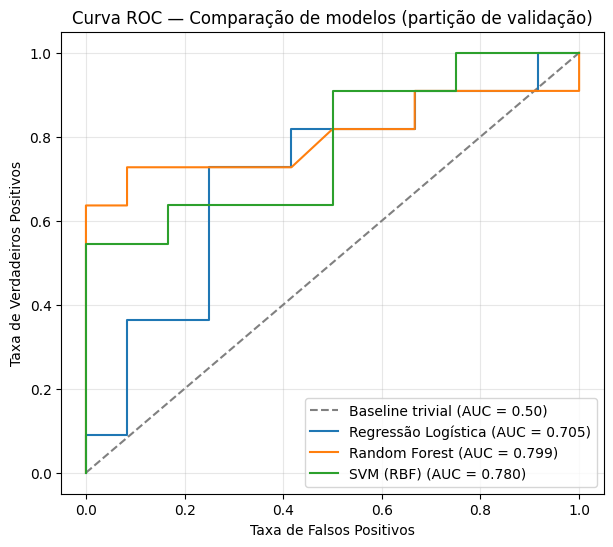

In [12]:
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Baseline trivial (AUC = 0.50)")
for nome, pipe in modelos.items():
    proba = pipe.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc_modelo = roc_auc_score(y_val, proba)
    plt.plot(fpr, tpr, label=f"{nome} (AUC = {auc_modelo:.3f})")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC — Comparação de modelos (partição de validação)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/curva_roc.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
from sklearn.model_selection import GridSearchCV

parametros = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}

pipe_rf = Pipeline([
    ("clf", RandomForestClassifier(random_state=SEED, class_weight="balanced"))
])

grid = GridSearchCV(pipe_rf, parametros, cv=cv, scoring="roc_auc", n_jobs=-1)
grid.fit(X_treino, y_treino)

print("Melhores hiperparâmetros encontrados (via CV no treino):")
print(grid.best_params_)
print(f"Melhor AUC-ROC na CV: {grid.best_score_:.3f}")

melhor_modelo = grid.best_estimator_
proba_final = melhor_modelo.predict_proba(X_val)[:, 1]
pred_final = melhor_modelo.predict(X_val)

print(f"\nAvaliação na validação com hiperparâmetros ajustados:")
print(f"AUC-ROC: {roc_auc_score(y_val, proba_final):.3f}")
print(f"F1: {f1_score(y_val, pred_final, zero_division=0):.3f}")
print(f"Acurácia balanceada: {balanced_accuracy_score(y_val, pred_final):.3f}")
print("Matriz de confusão:")
print(confusion_matrix(y_val, pred_final))

Melhores hiperparâmetros encontrados (via CV no treino):
{'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 300}
Melhor AUC-ROC na CV: 0.649

Avaliação na validação com hiperparâmetros ajustados:
AUC-ROC: 0.811
F1: 0.727
Acurácia balanceada: 0.739
Matriz de confusão:
[[9 3]
 [3 8]]


Total de erros do Random Forest na validação: 6 de 23
              StudyInstanceUID  real  pred
90    1.2.826.0.1.3680043.6854     1     0
101   1.2.826.0.1.3680043.9324     1     0
102  1.2.826.0.1.3680043.17210     0     1
103  1.2.826.0.1.3680043.16534     1     0
106  1.2.826.0.1.3680043.18188     0     1
109  1.2.826.0.1.3680043.32534     0     1


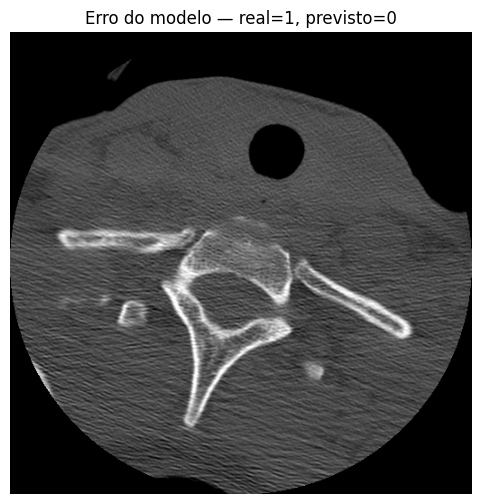

In [14]:
val_com_id = val.copy()
val_com_id["pred"] = modelos["Random Forest"].predict(X_val)
val_com_id["real"] = y_val.values

errados = val_com_id[val_com_id["pred"] != val_com_id["real"]]
print(f"Total de erros do Random Forest na validação: {len(errados)} de {len(val_com_id)}")
print(errados[["StudyInstanceUID", "real", "pred"]])

if len(errados) > 0:
    exemplo_erro = errados.iloc[0]
    study_uid_erro = exemplo_erro["StudyInstanceUID"]
    pasta = os.path.join(base_imagens, study_uid_erro)
    arquivos = sorted(os.listdir(pasta))
    ds = pydicom.dcmread(os.path.join(pasta, arquivos[len(arquivos) // 2]))
    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    img_hu = ds.pixel_array.astype(float) * slope + intercept
    img_janela = np.clip(img_hu, WINDOW_CENTER - WINDOW_WIDTH / 2, WINDOW_CENTER + WINDOW_WIDTH / 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_janela, cmap="gray")
    plt.title(f"Erro do modelo — real={exemplo_erro['real']}, previsto={exemplo_erro['pred']}")
    plt.axis("off")
    plt.savefig("/kaggle/working/exemplo_erro.png", dpi=150, bbox_inches="tight")
    plt.show()